<a href="https://colab.research.google.com/github/Sarthak-Rajvaidya/Artificial-Neural-Network-with-PyTorch/blob/main/ANN_Customer_Churn_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 🧠 Artificial Neural Network with PyTorch
## Customer Churn Prediction

# This project implements an Artificial Neural Network using PyTorch
# for binary classification.

# ### Concepts covered

# - Data preprocessing
# - Tensor conversion
# - ANN architecture
# - Input layer
# - Hidden layers
# - Activation functions
# - Forward propagation
# - Loss function
# - Backpropagation
# - Gradient Descent
# - Optimizers
# - Training loop
# - Evaluation
# - Predictions

In [2]:
# imported all required libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix



In [3]:
print(torch.__version__)

2.11.0+cpu


In [4]:
df = pd.read_csv("Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 14)

In [7]:
#Seperate input and target
X = df.drop(['RowNumber','CustomerId','Surname'],axis = 1)
y = df["Exited"]

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [10]:
#encode categorical data
X = pd.get_dummies(
    X,
    columns=["Geography","Gender"],
    drop_first = True
)

In [11]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [12]:
#6 Convert to numpy
X= X.astype(np.float32).values
y = y.astype(np.float32).values


In [13]:
print(X.shape)
print(y.shape)

(10000, 12)
(10000,)


In [14]:
from re import split
#step 7 Train test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# stratify =y :- Maintain approximately the same class distribution in both training and testing data

In [15]:
#Step 8 :- Standardize the feature
#USe standarScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#fit_transform → learn + apply
#transform → apply only


In [16]:
# Why not fit_transform(X_test)??
# Ans :- Beacuse now we are calculationg new means and standard deviatoin from data .
# therefore test data is used to influence preprocessing
# So this can cause u data leakage thats why



In [17]:
#Step 9 :- Convert data into PyTorch tensors

#Pytorch neural networks work with tensors

X_train_tensor = torch.tensor(X_train,dtype = torch.float32)
X_test_tensor = torch.tensor(X_test,dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train,
    dtype = torch.float32
).reshape(-1,1)


y_test_tensor = torch.tensor(
    y_test,
    dtype = torch.float32
).reshape(-1,1)

In [18]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([8000, 12])
torch.Size([8000, 1])


In [23]:
#step 10 :- Actual ANN implementation

class ChurnANN(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(12,16)
    self.layer2 = nn .Linear(16,8)
    self.output = nn.Linear(8,1)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.layer1(x)
    x = self.relu(x)
    x = self.layer2(x)
    x = self.relu(x)
    x = self.output(x)
    x = self.sigmoid(x)

    return x



In [24]:
model = ChurnANN()
print(model)

ChurnANN(
  (layer1): Linear(in_features=12, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [ ]:
#nn.Linear(12,16)  means 12 inputs -> 16 neurons Z1 = Wx1+b1
#nn.Linear(16,8) means 16 neurons -> 8 neurons Z2 = A1W2+b2
#nn.Linear(8,1) 8 neurons -> 1 output neuron

In [25]:
#step 11 :- Move model to GPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

In [26]:
print(device)

cpu


In [27]:
model = ChurnANN().to(device)

X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

In [28]:
#step 12 :- Loss Function
# As this is binary classification we need Binaery Cross Entropy

criterion = nn.BCELoss()


In [29]:
#step 13 :- Optimizer
#Start with adam thats best

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [32]:
#step 14 :- Training Loop

epochs = 100
loss_history = []

for epoch in range(epochs):

  #Forward Propagation
  predictions = model(X_train_tensor)

  #Calculate Loss

  loss = criterion(
      predictions,
      y_train_tensor
  )

  #clear old gradients
  optimizer.zero_grad()

  #Backpropgaation
  loss.backward()


  #update weights
  optimizer.step()

  loss_history.append(loss.item())

  if(epoch +1 )%10 == 0:
    print(
        f"Epoch [{epoch+1}/{epochs}],"
        f"Loss : {loss.item():.4f}"
    )


Epoch [10/100],Loss : 0.6161
Epoch [20/100],Loss : 0.5936
Epoch [30/100],Loss : 0.5714
Epoch [40/100],Loss : 0.5486
Epoch [50/100],Loss : 0.5246
Epoch [60/100],Loss : 0.4990
Epoch [70/100],Loss : 0.4719
Epoch [80/100],Loss : 0.4436
Epoch [90/100],Loss : 0.4147
Epoch [100/100],Loss : 0.3855


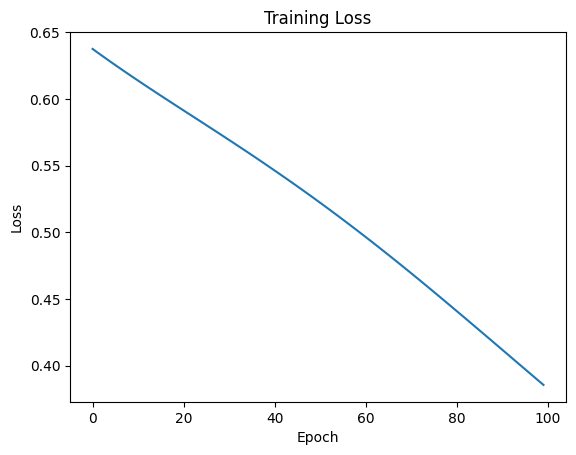

In [33]:
#step 15:- Plot training Loss
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [35]:
#step 16 - eValuet the model
model.eval()

with torch.no_grad():
  predictions = model(X_test_tensor)


In [36]:
#Convert Probbailites into classes
predicted_classes = (
    predictions >= 0.5
).float()

In [37]:
accuracy = (
    predicted_classes == y_test_tensor

).float().mean()

print("Accuracy:",accuracy.item)

Accuracy: <built-in method item of Tensor object at 0x7956787d6530>


In [38]:
# step 17 :- Classification Report
#Move predictions back to CPU

y_pred = predicted_classes.cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.81      1.00      0.89      1593
         1.0       1.00      0.06      0.11       407

    accuracy                           0.81      2000
   macro avg       0.90      0.53      0.50      2000
weighted avg       0.85      0.81      0.73      2000



In [39]:
#step 18 :- Confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)
print(cm)

[[1593    0]
 [ 384   23]]


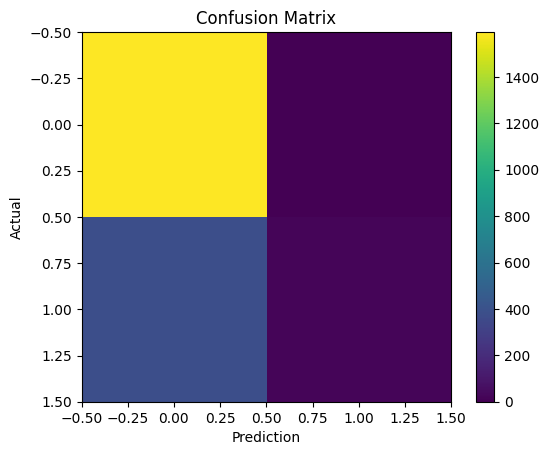

In [40]:
plt.imshow(cm)
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()